In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Dataset for Data Analytics to Dataset for Data Analytics


In [7]:
df = pd.read_excel('Dataset for Data Analytics')

In [8]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [9]:
df.shape

(1200, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [11]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [12]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [15]:
product_sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
print(product_sales)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


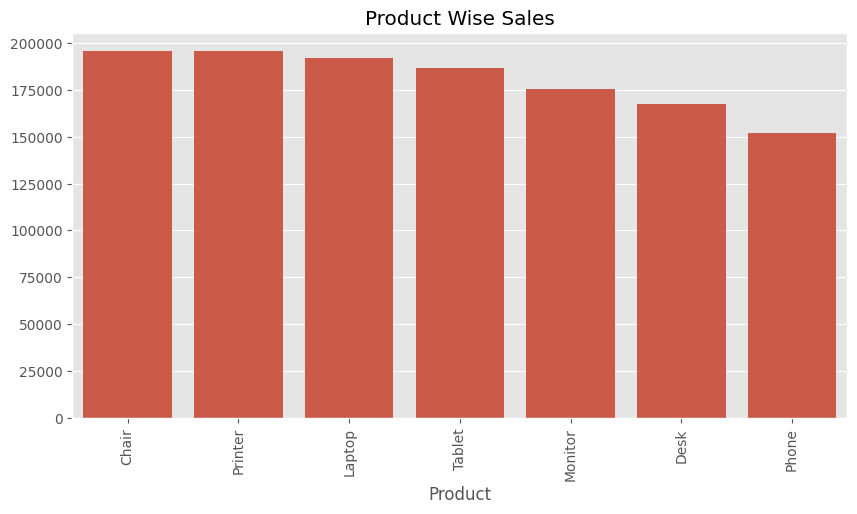

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    x=product_sales.index,
    y=product_sales.values
)
plt.xticks(rotation=90)
plt.title('Product Wise Sales')
plt.show()

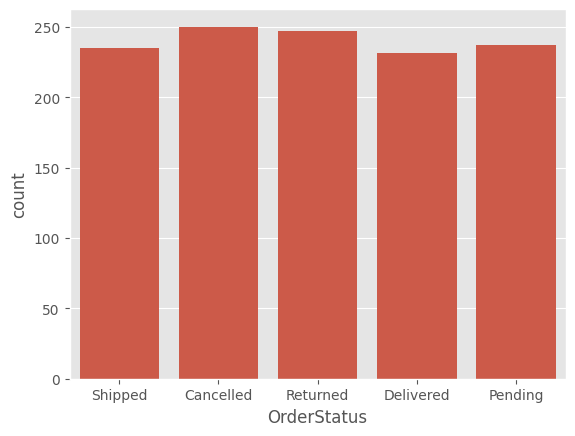

In [17]:
sns.countplot(data=df, x='OrderStatus')
plt.show()

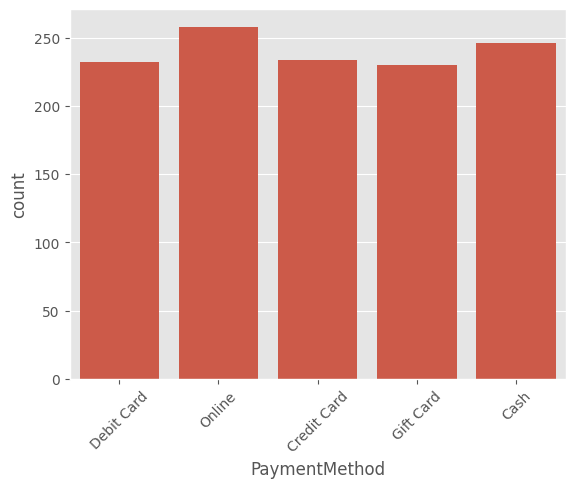

In [18]:
sns.countplot(data=df, x='PaymentMethod')
plt.xticks(rotation=45)
plt.show()

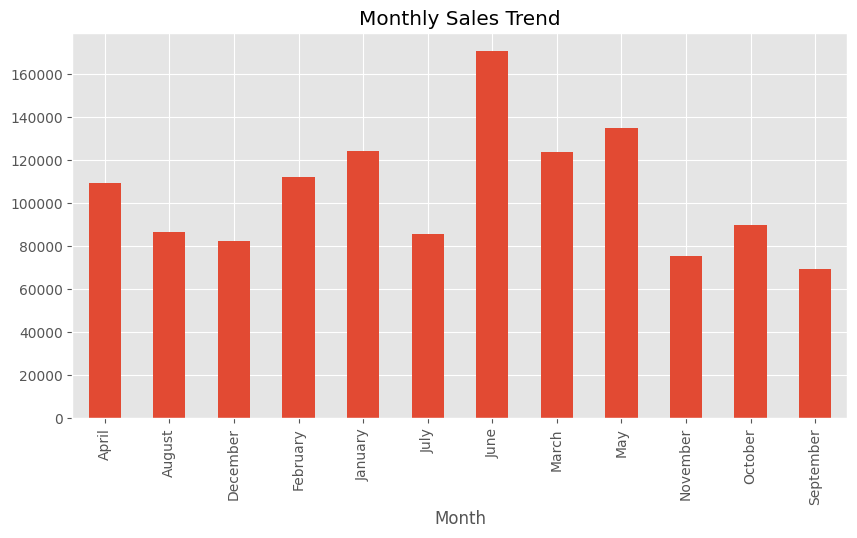

In [19]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.show()

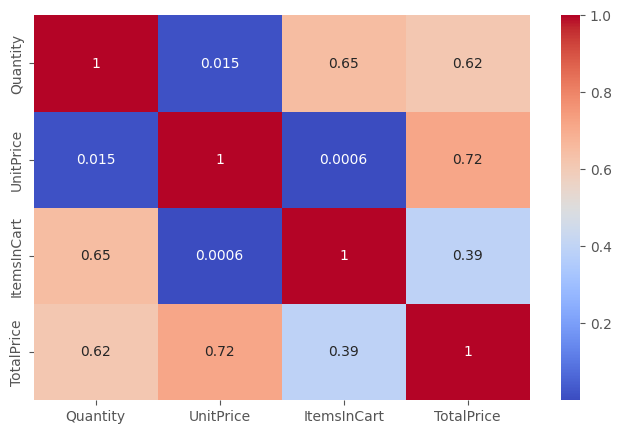

In [20]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

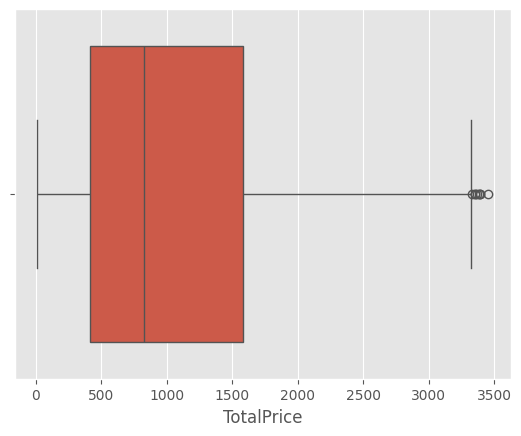

In [21]:
sns.boxplot(x=df['TotalPrice'])
plt.show()

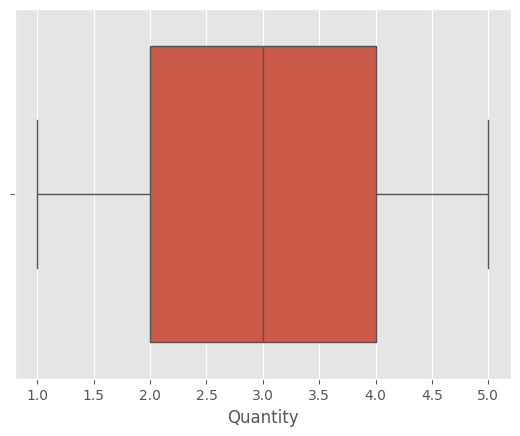

In [24]:
sns.boxplot(x=df['Quantity'])
plt.show()

In [25]:
# Highest selling product
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

,TotalPrice
Product,
Chair,195620.11
Printer,195612.61
Laptop,192126.56
Tablet,186568.95
Monitor,175651.41
Desk,167459.93
Phone,151722.39


In [26]:
# Most used payment method
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [27]:
# Order status distribution
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [28]:
# Referral source distribution
df['ReferralSource'].value_counts()

,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


In [29]:
print("EDA COMPLETED SUCCESSFULLY")
print("Total Orders :", len(df))
print("Highest Revenue Product : Chair")
print("Most Used Payment Method : Online")
print("Most Common Order Status : Cancelled")
print("Top Referral Source : Instagram")
print("Business Insights Generated Successfully")

EDA COMPLETED SUCCESSFULLY
Total Orders : 1200
Highest Revenue Product : Chair
Most Used Payment Method : Online
Most Common Order Status : Cancelled
Top Referral Source : Instagram
Business Insights Generated Successfully
